In [34]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def load_data(file_path, plot_data=True, xrange=None, yrange=None, axhline_val=None):

    with open(file_path) as f:
        data = json.load(f)

    for _, v in data.items():
        v['z_edges'] = np.array(v['z_edges'])
        v['means'] = np.array(v['means'])
        v['stdevs'] = np.array(v['stdevs'])
        v['cov'] = np.array(v['cov'])

    if plot_data:

        fig, axes = plt.subplots(2, 3, figsize=(12, 6), gridspec_kw={
                                 'wspace': 0, 'hspace': 0})

        folder_names = data.keys()

        for i, folder_name in enumerate(folder_names):

            z_edges = data[folder_name]['z_edges']
            means = data[folder_name]['means']
            stdevs = data[folder_name]['stdevs']

            row_n = 0 if (i < 3) else 1
            col_n = i if (i < 3) else i - 3

            ax = axes[row_n, col_n]

            band_color = 'seagreen' if 'sdss' in folder_name else 'steelblue'

            for j in range(len(means)):
                ax.fill_between([z_edges[j], z_edges[j+1]], [means[j]-stdevs[j]]
                                * 2, [means[j]+stdevs[j]]*2, color=band_color, alpha=0.66)
            ax.fill_between([-10], [-10], [-10], color=band_color,
                            alpha=0.66, label=folder_name)
            ax.legend(loc='upper left', frameon=False, fontsize=12)

            if i not in [0, 3]:
                ax.set_yticklabels([])
            if i < 3:
                ax.set_xticklabels([])

            ax.set_xlim(xrange)
            ax.set_ylim(yrange)

            ax.axhline(axhline_val, color='black', ls='dashed')

    return data

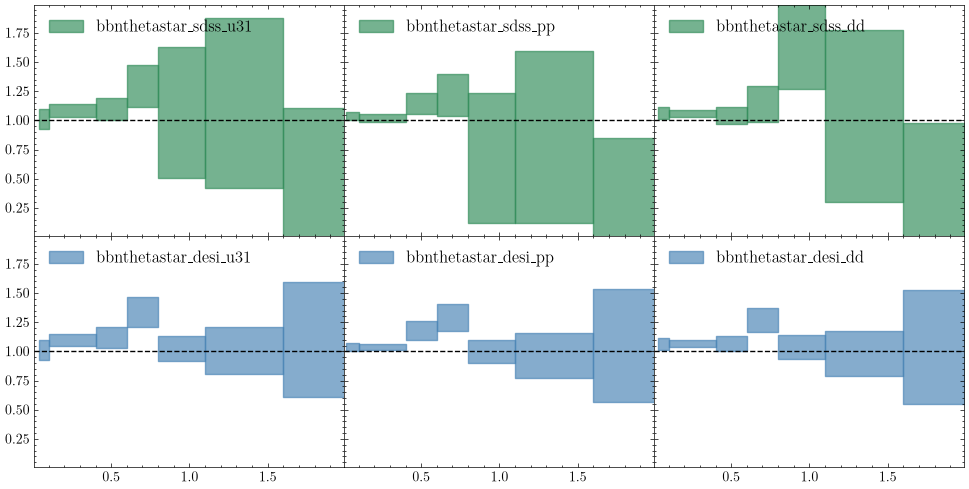

In [36]:
fde_data = load_data('fde_results.json', plot_data=True, xrange=[
                     0.01, 1.99], yrange=[0.01, 1.99], axhline_val=1)

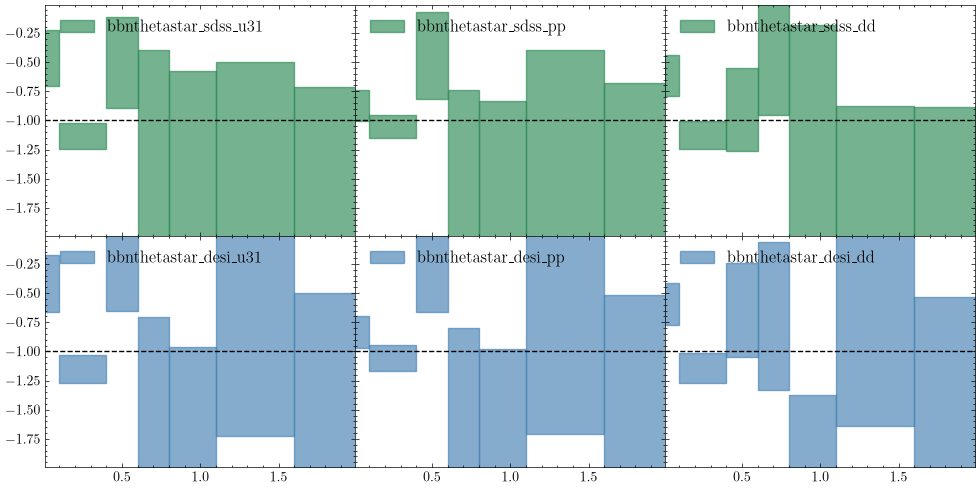

In [37]:
wde_data = load_data('wde_results.json', plot_data=True, xrange=[
                     0.01, 1.99], yrange=[-1.99, -0.01], axhline_val=-1)

## Combined $w_{\rm DE}(z)$ / $f_{\rm DE}(z)$ reconstruction plot -- PP+DESI vs DD+DESI

2x2 grid, same panel style as the $H(z)/(1+z)$, $w(z)$ figure in `grea_bestfit.ipynb`
(`sharex=True`/`sharey` per row, `hspace=0`/`wspace=0`, `science` style if
available): $w_{\rm DE}(z)$ on the top row, $f_{\rm DE}(z)$ on the bottom row;
PP+DESI in the left column, DD+DESI in the right column. Each panel overlays:

- the redshift-binned reconstruction blocks (mean $\pm 1\sigma$ per bin, now with
  a black border) for the `bbnthetastar_desi_pp` / `bbnthetastar_desi_dd` runs
  loaded above, and
- the corresponding **GREA best-fit curve** with **1$\sigma$/2$\sigma$ bands**,
  obtained the same way as in `grea_bestfit.ipynb`: minimum-`minuslogpost`
  sample (best fit) plus `N_DRAWS` weighted posterior draws from the matching
  Cobaya chain, each run through CLASS (background only) to get $w(z)$ =
  `(.)w_fld` and $f_{\rm DE}(z) \equiv \rho_{\rm fld}(z)/\rho_{\rm fld}(z{=}0)$;
  the bands are pointwise 16/84 and 2.5/97.5 percentiles of the draws.

Chain used for PP+DESI: `grea_Run1_PP+DESI` (no extra prior). Chain used for
DD+DESI: `grea_Run9_CMB-SPA+DESDovekie+DESI` -- there is no plain
"DD+DESI-only" GREA chain in the repo, so this is the closest available
proxy; it also carries an additional CMB-SPA prior, so it isn't a perfect
dataset match to the PP+DESI panel.

In [38]:
import os
import sys
import glob
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

try:
    import scienceplots  # noqa: F401 -- registers the "science" style
    plt.style.use(["science"])
except ImportError:
    pass

OUT_DIR = "figs"
os.makedirs(OUT_DIR, exist_ok=True)

# column -> (reconstruction-block json key, GREA chain root, block color)
PANELS = {
    "CMB-SPA+PP+DESI": dict(key="bbnthetastar_desi_pp",
                            chain="../grea_Run3_CMB-SPA+PP+DESI/chains/chains",
                            color="#DC24FF"),
    "CMB-SPA+DESDovekie+DESI": dict(key="bbnthetastar_desi_dd",
                                    chain="../grea_Run9_CMB-SPA+DESDovekie+DESI/chains/chains",
                                    color="#847BFF"),
}


def plot_blocks(ax, data, key, color, alpha=0.55, edgecolor="k", edgewidth=1.0, zorder=2):
    """Draw the per-bin mean +/- 1sigma reconstruction as bordered step blocks."""
    v = data[key]
    z_edges, means, stdevs = v["z_edges"], v["means"], v["stdevs"]
    for j in range(len(means)):
        lo, hi = means[j] - stdevs[j], means[j] + stdevs[j]
        ax.fill_between([z_edges[j], z_edges[j + 1]], [lo] * 2, [hi] * 2,
                        color=color, alpha=alpha, lw=0, zorder=zorder)
        ax.plot([z_edges[j], z_edges[j + 1], z_edges[j + 1], z_edges[j], z_edges[j]],
                [lo, lo, hi, hi, lo],
                color=edgecolor, lw=edgewidth, zorder=zorder + 0.5)

In [39]:
# --- CLASS + Cobaya-chain setup, mirroring grea_bestfit.ipynb -------------
from classy import Class
from getdist import loadMCSamples

_cwd = os.getcwd()
_CLASS_ROOT = None
for _candidate in [
    os.path.join(_cwd, "class_public-3.3.4"),              # cwd = repo root
    os.path.join(_cwd, "..", "class_public-3.3.4"),        # cwd = ANALYSIS/
    # cwd = ANALYSIS/Recostruction/
    os.path.join(_cwd, "..", "..", "class_public-3.3.4"),
]:
    if os.path.exists(os.path.join(_candidate, "source", "background.c")):
        _CLASS_ROOT = os.path.abspath(_candidate)
        break
if _CLASS_ROOT is None:
    raise RuntimeError(
        "Cannot find class_public-3.3.4/ near the current working directory.")
CLASS_ROOT = _CLASS_ROOT
sys.path.insert(0, os.path.join(CLASS_ROOT, "python"))

_C_KMS = 2.99792458e5  # speed of light, km/s

_COMMON = {
    "N_ncdm": 1, "N_ur": 2.046, "m_ncdm": 0.06,
    "sBBN file": "external/bbn/sBBN_2017.dat",
    "base_path": CLASS_ROOT + "/",
    "tau_reio": 0.06, "A_s": 2.1e-9, "n_s": 0.9649,
    "output": "",
}

GREA_PARAMS = ["H0", "omega_b", "omega_cdm", "sqrt_k_eta0"]
IGNORE_ROWS = 0.3
N_DRAWS = 150
Z_GRID = np.linspace(1e-3, 2.6, 200)


def best_fit_and_draws(chain_root, params=GREA_PARAMS, ignore_rows=IGNORE_ROWS,
                       n_draws=N_DRAWS, seed=0):
    s = loadMCSamples(chain_root, settings={"ignore_rows": ignore_rows})
    names = s.getParamNames().list()
    idx = [names.index(p) for p in params]
    samp = s.samples[:, idx]
    loglikes = s.loglikes
    weights = s.weights

    bf = dict(zip(params, samp[np.argmin(loglikes)]))
    print(f"{chain_root}: {int(s.numrows)} samples | "
          f"R-1(worst) = {s.getGelmanRubin():.4f} | best fit = {bf}")

    rng = np.random.default_rng(seed)
    probs = weights / weights.sum()
    draw_idx = rng.choice(len(weights), size=n_draws, replace=True, p=probs)
    draws = [dict(zip(params, samp[i])) for i in draw_idx]
    return bf, draws


def build_grea(p):
    c = Class()
    c.set({**_COMMON, "fluid_equation_of_state": "GREA", "cs2_fld": 1.0, "use_ppf": "yes",
           "H0": p["H0"], "omega_b": p["omega_b"], "omega_cdm": p["omega_cdm"],
           "sqrt_k_eta0": p["sqrt_k_eta0"]})
    c.compute()
    return c


def wde_fde_curves(c, z_grid):
    """w(z) and f_DE(z) = rho_fld(z) / rho_fld(z=0)."""
    bg = c.get_background()
    z_bg = np.array(bg["z"])
    order = np.argsort(z_bg)
    z_bg = z_bg[order]
    w_bg = np.array(bg["(.)w_fld"])[order]
    rho_bg = np.array(bg["(.)rho_fld"])[order]
    rho0 = rho_bg[np.argmin(z_bg)]  # z=0 value

    wz = np.interp(z_grid, z_bg, w_bg)
    fz = np.interp(z_grid, z_bg, rho_bg) / rho0
    c.struct_cleanup()
    return dict(w=wz, f=fz)


def pct_bands(arr):
    return dict(
        lo2=np.percentile(arr, 2.5, axis=0), lo1=np.percentile(arr, 16, axis=0),
        hi1=np.percentile(arr, 84, axis=0), hi2=np.percentile(arr, 97.5, axis=0),
    )


print("Computing GREA best-fit curves + 1sigma/2sigma bands for each panel...")
for label, cfg in PANELS.items():
    bf, draws = best_fit_and_draws(cfg["chain"])
    cfg["curves"] = wde_fde_curves(build_grea(bf), Z_GRID)

    draw_stack = {"w": [], "f": []}
    for i, p in enumerate(draws):
        cv = wde_fde_curves(build_grea(p), Z_GRID)
        draw_stack["w"].append(cv["w"])
        draw_stack["f"].append(cv["f"])
        if (i + 1) % 50 == 0:
            print(f"  {label}: {i + 1}/{N_DRAWS}")
    cfg["bands"] = {k: pct_bands(np.array(v)) for k, v in draw_stack.items()}
print("Done.")

Computing GREA best-fit curves + 1sigma/2sigma bands for each panel...
../grea_Run3_CMB-SPA+PP+DESI/chains/chains: 10396 samples | R-1(worst) = 0.0116 | best fit = {'H0': np.float64(67.900117), 'omega_b': np.float64(0.022416292), 'omega_cdm': np.float64(0.11873014), 'sqrt_k_eta0': np.float64(3.3205036)}
  CMB-SPA+PP+DESI: 50/150
  CMB-SPA+PP+DESI: 100/150
  CMB-SPA+PP+DESI: 150/150
../grea_Run9_CMB-SPA+DESDovekie+DESI/chains/chains: 21574 samples | R-1(worst) = 0.0156 | best fit = {'H0': np.float64(67.30051), 'omega_b': np.float64(0.022427272), 'omega_cdm': np.float64(0.11844814), 'sqrt_k_eta0': np.float64(3.2156627)}
  CMB-SPA+DESDovekie+DESI: 50/150
  CMB-SPA+DESDovekie+DESI: 100/150
  CMB-SPA+DESDovekie+DESI: 150/150
Done.


saved -> figs/reconstruction_wde_fde.pdf


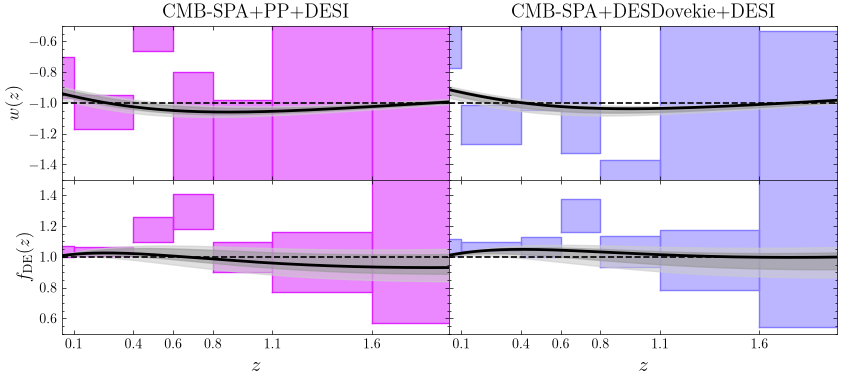

In [42]:
fig, axes = plt.subplots(
    2, 2, figsize=(10., 4.), sharex=True, sharey="row",
    gridspec_kw={"height_ratios": [1., 1], "hspace": 0.0, "wspace": 0.0},
)

Z_TICKS = [0.1, 0.4, 0.6, 0.8, 1.1, 1.6]

for col, (label, cfg) in enumerate(PANELS.items()):
    ax_w, ax_f = axes[0, col], axes[1, col]

    ax_w.fill_between(Z_GRID, cfg["bands"]["w"]["lo2"], cfg["bands"]["w"]["hi2"],
                      color="0.8", alpha=0.6, zorder=1)
    ax_w.fill_between(Z_GRID, cfg["bands"]["w"]["lo1"], cfg["bands"]["w"]["hi1"],
                      color="0.6", alpha=0.6, zorder=1)
    ax_f.fill_between(Z_GRID, cfg["bands"]["f"]["lo2"], cfg["bands"]["f"]["hi2"],
                      color="0.8", alpha=0.6, zorder=1)
    ax_f.fill_between(Z_GRID, cfg["bands"]["f"]["lo1"], cfg["bands"]["f"]["hi1"],
                      color="0.6", alpha=0.6, zorder=1)

    plot_blocks(ax_w, wde_data, cfg["key"],
                cfg["color"], edgecolor=cfg["color"], zorder=-2)
    plot_blocks(ax_f, fde_data, cfg["key"],
                cfg["color"], edgecolor=cfg["color"], zorder=-2)

    ax_w.plot(Z_GRID, cfg["curves"]["w"], color="k", lw=2, zorder=4)
    ax_f.plot(Z_GRID, cfg["curves"]["f"], color="k", lw=2, zorder=4)

    ax_w.axhline(-1.0, color="k", lw=1.2, ls="--", zorder=1)
    ax_f.axhline(1.0, color="k", lw=1.2, ls="--", zorder=1)

    ax_w.set_title(label, fontsize=14)

    legend_handles = [
        mpatches.Patch(facecolor=cfg["color"], edgecolor="k", lw=0.8,
                       alpha=0.55, label="reconstruction"),
        Line2D([0], [0], color="k", lw=2, label="GREA best fit"),
        mpatches.Patch(facecolor="0.6", alpha=0.5, label=r"GREA $1\sigma$"),
        mpatches.Patch(facecolor="0.8", alpha=0.5, label=r"GREA $2\sigma$"),
    ]
    # ax_w.legend(handles=legend_handles, loc="upper left",
    #            fontsize=8, frameon=False)

    ax_f.set_xlabel(r"$z$", fontsize=15)
    ax_f.set_xlim(0.04, 1.99)
    ax_w.set_xlim(0.04, 1.99)

    ax_f.set_xticks(Z_TICKS)
    ax_w.xaxis.set_minor_locator(mticker.NullLocator())
    ax_f.xaxis.set_minor_locator(mticker.NullLocator())


axes[0, 0].set_ylabel(r"$w(z)$", fontsize=13)
axes[0, 0].set_ylim(-1.99, -0.01)
axes[0, 0].set_ylim(-1.5, -0.5)
axes[1, 0].set_ylabel(r"$f_{\rm DE}(z)$", fontsize=13)
axes[1, 0].set_ylim(0.01, 1.99)
axes[1, 0].set_ylim(0.5, 1.5)

fig.savefig(os.path.join(OUT_DIR, "reconstruction_wde_fde.pdf"),
            dpi=300, bbox_inches="tight")
print("saved -> figs/reconstruction_wde_fde.pdf")
plt.show()